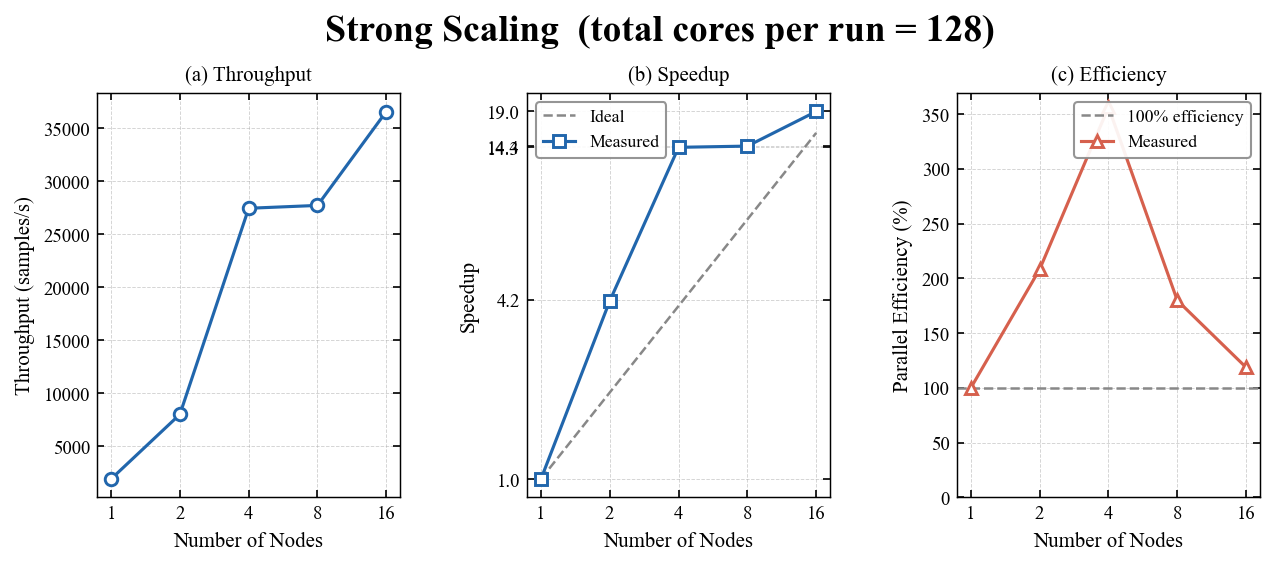

Saved → strong_scaling.pdf  and  strong_scaling.png

 Nodes    PPN   Latency(ms)   Std(ms)    Throughput   Speedup   Eff(%)
──────────────────────────────────────────────────────────────────────
     1    128        66.429    3.2986      1926.880     1.000x   100.0%
     2     64        31.896    4.9005      8025.980     4.165x   208.3%
     4     32        18.642    6.1436     27465.600    14.254x   356.3%
     8     16        36.922   13.3966     27734.200    14.393x   179.9%
    16      8        55.965   28.0511     36594.000    18.991x   118.7%


In [7]:
"""
Strong Scaling Plot  ·  Drop into a Jupyter cell and run
==========================================================
File-name convention : {nodes}_{ppn}.out
Filter               : nodes × ppn == TOTAL_CORES (default 128)
Extracts             : Mean latency, Std dev, Throughput
"""

# ── 0. Imports ────────────────────────────────────────────────────────────────
import os, re, glob
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

# ── 1. Configuration  (edit these) ───────────────────────────────────────────
DATA_DIR     = "results"       # folder that contains your .out files
TOTAL_CORES  = 128       # keep only nodes × ppn == this value
OUT_PDF      = "strong_scaling.pdf"
OUT_PNG      = "strong_scaling.png"


# ── 2. Parser ────────────────────────────────────────────────────────────────
def parse_out_file(path: str):
    """Return (mean_latency_ms, std_ms, throughput_sps) or None."""
    text = Path(path).read_text(errors="replace")
    m_lat = re.search(r"Mean latency\s*:\s*([\d.]+)\s*ms",    text)
    m_std = re.search(r"Std dev\s*:\s*([\d.]+)\s*ms",         text)
    m_thr = re.search(r"Throughput\s*:\s*([\d.]+)\s*samples", text)
    if not (m_lat and m_std and m_thr):
        return None
    return float(m_lat.group(1)), float(m_std.group(1)), float(m_thr.group(1))


# ── 3. Collect & filter ──────────────────────────────────────────────────────
records = []
for fpath in sorted(glob.glob(os.path.join(DATA_DIR, "*.out"))):
    fname = os.path.basename(fpath)
    m = re.match(r"^(\d+)_(\d+)\.out$", fname)
    if not m:
        continue
    nodes, ppn = int(m.group(1)), int(m.group(2))
    if nodes * ppn != TOTAL_CORES:
        continue                          # e.g. 2_128 → 256 cores → skip
    result = parse_out_file(fpath)
    if result is None:
        print(f"  [warn] could not parse {fname} — skipping")
        continue
    lat, std, thr = result
    records.append(dict(nodes=nodes, ppn=ppn,
                        latency=lat, std=std, throughput=thr))

records.sort(key=lambda r: r["nodes"])

if not records:
    raise RuntimeError(
        f"No valid .out files found in '{DATA_DIR}' with nodes×ppn={TOTAL_CORES}.\n"
        "Check DATA_DIR and TOTAL_CORES."
    )

# ── 4. Derived arrays ────────────────────────────────────────────────────────
nodes_arr = np.array([r["nodes"]      for r in records])
thr_arr   = np.array([r["throughput"] for r in records])
lat_arr   = np.array([r["latency"]    for r in records])
std_arr   = np.array([r["std"]        for r in records])
ppn_arr   = np.array([r["ppn"]        for r in records])

baseline  = thr_arr[0]
speedup   = thr_arr / baseline
efficiency = speedup / (nodes_arr / nodes_arr[0]) * 100   # percent

# Ideal lines
x_ideal = np.array([nodes_arr[0], nodes_arr[-1]], dtype=float)
y_ideal = x_ideal / nodes_arr[0]


# ── 5. Matplotlib RC: IEEE / NeurIPS / ICML style ────────────────────────────
mpl.rcParams.update({
    # Font — Times New Roman keeps it journal-ready
    "font.family"          : "serif",
    "font.serif"           : ["Times New Roman", "Liberation Serif", "DejaVu Serif"],
    "font.size"            : 10,
    "axes.titlesize"       : 10,
    "axes.labelsize"       : 10,
    "xtick.labelsize"      : 9,
    "ytick.labelsize"      : 9,
    "legend.fontsize"      : 8.5,
    "legend.framealpha"    : 0.92,
    "legend.edgecolor"     : "0.55",
    "legend.handlelength"  : 1.8,
    # Lines
    "lines.linewidth"      : 1.5,
    "lines.markersize"     : 6,
    # Axes
    "axes.linewidth"       : 0.7,
    "axes.spines.top"      : True,
    "axes.spines.right"    : True,
    "xtick.direction"      : "in",
    "ytick.direction"      : "in",
    "xtick.top"            : True,
    "ytick.right"          : True,
    "xtick.major.size"     : 3.5,
    "ytick.major.size"     : 3.5,
    "xtick.minor.size"     : 2.0,
    "ytick.minor.size"     : 2.0,
    # Grid
    "axes.grid"            : True,
    "grid.linestyle"       : "--",
    "grid.linewidth"       : 0.45,
    "grid.alpha"           : 0.55,
    # Output
    "figure.dpi"           : 150,
    "savefig.dpi"          : 300,
    "savefig.bbox"         : "tight",
    "pdf.fonttype"         : 42,   # embed fonts (required by many venues)
    "ps.fonttype"          : 42,
})

# Colour palette — muted, print-friendly
C_BLUE  = "#2166AC"   # throughput / speedup measured
C_RED   = "#D6604D"   # efficiency
C_GRAY  = "#888888"   # ideal


# ── 6. Layout: 3-panel figure ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))   # ~double-column width
fig.subplots_adjust(wspace=0.42)

# ── Panel (a): Throughput ─────────────────────────────────────────────────────
ax = axes[0]
ax.plot(nodes_arr, thr_arr, "o-", color=C_BLUE,
        markerfacecolor="white", markeredgewidth=1.4, zorder=3)
ax.set_xlabel("Number of Nodes")
ax.set_ylabel("Throughput (samples/s)")
ax.set_title("(a) Throughput")
ax.set_xscale("log", base=2)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xticks(nodes_arr)
ax.set_xticklabels(nodes_arr)

# ── Panel (b): Strong-scaling speedup ────────────────────────────────────────
ax = axes[1]
ax.plot(x_ideal, y_ideal, "--", color=C_GRAY, linewidth=1.2,
        label="Ideal", zorder=2)
ax.plot(nodes_arr, speedup, "s-", color=C_BLUE,
        markerfacecolor="white", markeredgewidth=1.4,
        label="Measured", zorder=3)
ax.set_xlabel("Number of Nodes")
ax.set_ylabel("Speedup")
ax.set_title("(b) Speedup")
ax.set_xscale("log", base=2)
ax.set_yscale("log", base=2)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xticks(nodes_arr)
ax.set_xticklabels(nodes_arr)
ax.set_yticks(np.unique(np.round(speedup, 1)))
ax.legend(loc="upper left")

# ── Panel (c): Parallel efficiency ───────────────────────────────────────────
ax = axes[2]
ax.axhline(100, linestyle="--", color=C_GRAY, linewidth=1.2,
           label="100% efficiency", zorder=2)
ax.plot(nodes_arr, efficiency, "^-", color=C_RED,
        markerfacecolor="white", markeredgewidth=1.4,
        label="Measured", zorder=3)
ax.set_xlabel("Number of Nodes")
ax.set_ylabel("Parallel Efficiency (%)")
ax.set_title("(c) Efficiency")
ax.set_xscale("log", base=2)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xticks(nodes_arr)
ax.set_xticklabels(nodes_arr)
ax.set_ylim(bottom=0)
ax.legend(loc="upper right")

# ── Shared super-title ───────────────────────────────────────────────────────
fig.suptitle(
    f"Strong Scaling  (total cores per run = {TOTAL_CORES})",
    fontsize=18, fontweight="bold", y=1.03
)

plt.savefig(OUT_PDF)
plt.savefig(OUT_PNG)
plt.show()
print(f"Saved → {OUT_PDF}  and  {OUT_PNG}")


# ── 7. Summary table ─────────────────────────────────────────────────────────
print()
header = f"{'Nodes':>6}  {'PPN':>5}  {'Latency(ms)':>12}  "      \
         f"{'Std(ms)':>8}  {'Throughput':>12}  {'Speedup':>8}  {'Eff(%)':>7}"
print(header)
print("─" * len(header))
for r, sp, ef in zip(records, speedup, efficiency):
    print(f"{r['nodes']:>6}  {r['ppn']:>5}  {r['latency']:>12.3f}  "
          f"{r['std']:>8.4f}  {r['throughput']:>12.3f}  {sp:>8.3f}x  {ef:>6.1f}%")